# 📊 Market Risk Dashboard — Quantitative Methods

**Author:** Athu  
**Project:** Market Risk Analytics | Multi-Asset Portfolio

---

## What This Notebook Covers

This notebook implements core **quantitative risk methods** used by market risk analysts and quant teams at investment banks and asset managers. You'll work through:

| Method | What It Measures | Industry Use |
|--------|-----------------|--------------|
| **Historical VaR** | Worst-case loss from past data | Regulatory reporting (Basel III) |
| **Parametric VaR** | Loss assuming normal returns | Quick daily risk estimates |
| **Monte Carlo VaR** | Loss from simulated scenarios | Complex/non-linear portfolios |
| **Expected Shortfall (CVaR)** | Average loss beyond VaR | Basel III preferred measure |
| **EWMA Volatility** | Time-weighted vol estimate | RiskMetrics / JP Morgan model |
| **Correlation Analysis** | Co-movement between assets | Portfolio construction |
| **Stress Testing** | Impact of crisis scenarios | Regulatory & internal risk |
| **Component VaR** | Each asset's risk contribution | Risk budgeting |

### Portfolio
- **Equities:** SPY (S&P 500), EFA (Int'l Developed), STW.AX (ASX 200)
- **Bonds:** TLT (US Long Treasury), AGG (US Agg Bond)
- **Commodities:** GLD (Gold), USO (Oil)


## 1. Setup & Imports

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


In [5]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


## 2. Data Acquisition

We pull **3 years of daily prices** for a multi-asset universe using `yfinance`. This gives us ~750 trading days — enough history for robust VaR estimation while keeping data relevant.

> 💡 **Why these assets?** A proper risk dashboard needs assets with *different risk-return profiles* and *varying correlations*. Bonds and gold often move inversely to equities during stress — that's the diversification benefit we want to measure.


In [13]:
# Define multi-asset universe
tickers = {
    'SPY':   'S&P 500',
    'EFA':   'Int\'l Developed',
    'STW.AX':'ASX 200',
    'TLT':   'US Long Treasury',
    'AGG':   'US Agg Bond',
    'GLD':   'Gold',
    'USO':   'Oil'
}

# Fetch 3 years of adjusted close prices
prices = yf.download(list(tickers.keys()), period='3y', auto_adjust=True)['Close']
prices = prices.dropna()

# Rename columns for readability
prices.columns = [tickers.get(c, c) for c in prices.columns]

print(f"Date range: {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(prices)}")
print(f"\nAssets loaded:")
for col in prices.columns:
    print(f"  • {col}")


[*********************100%***********************]  7 of 7 completed

Date range: 2023-04-03 to 2026-04-02
Trading days: 737

Assets loaded:
  • US Agg Bond
  • Int'l Developed
  • Gold
  • S&P 500
  • ASX 200
  • US Long Treasury
  • Oil


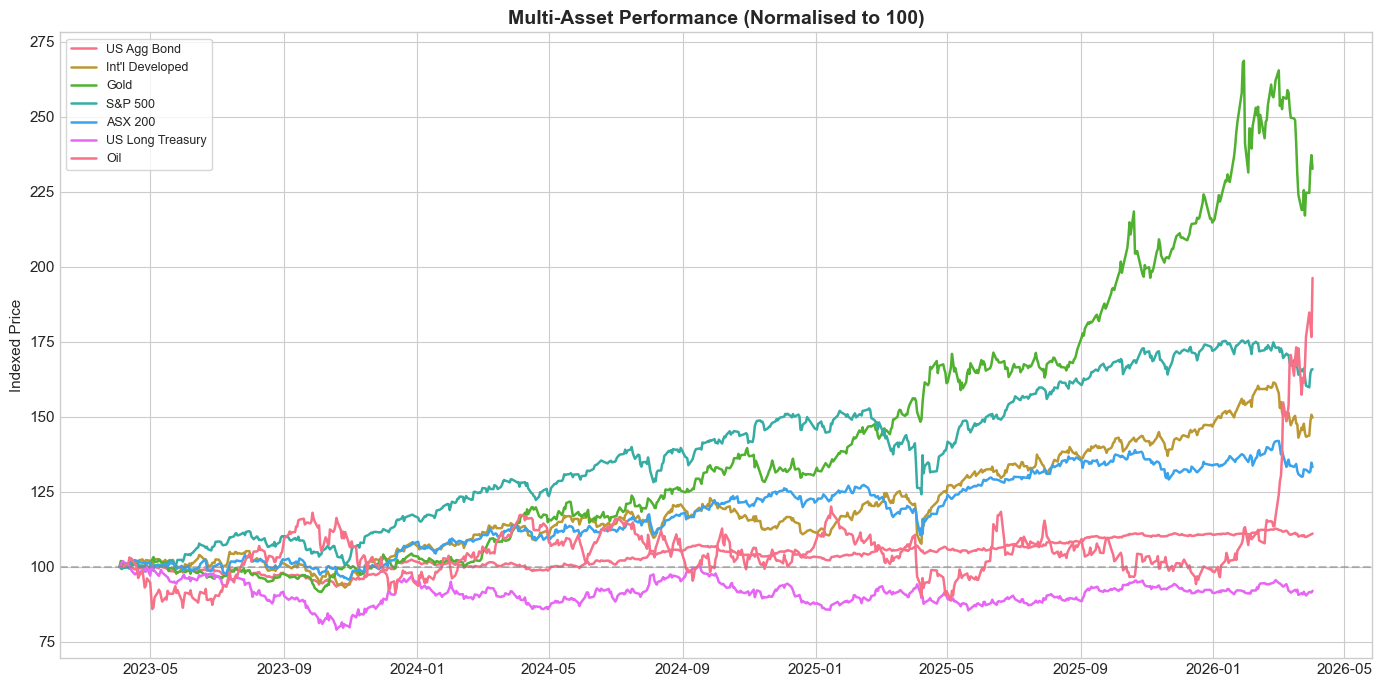

In [14]:
# Normalised price chart (base = 100)
normalised = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))
for col in normalised.columns:
    ax.plot(normalised.index, normalised[col], linewidth=1.8, label=col)
ax.set_title('Multi-Asset Performance (Normalised to 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Indexed Price')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.axhline(100, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Return Analysis

We compute **log returns** (continuously compounded). Log returns are preferred in quant finance because:
1. They're **time-additive** — you can sum daily log returns to get weekly/monthly returns
2. They're more likely to be **normally distributed** (an assumption we'll test)
3. They prevent **negative prices** in simulations

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$


In [15]:
# Calculate log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Summary statistics
summary = pd.DataFrame({
    'Ann. Return (%)': (returns.mean() * 252 * 100).round(2),
    'Ann. Volatility (%)': (returns.std() * np.sqrt(252) * 100).round(2),
    'Sharpe (Rf=4%)': (((returns.mean() * 252 - 0.04) / (returns.std() * np.sqrt(252)))).round(3),
    'Skewness': returns.skew().round(3),
    'Kurtosis': returns.kurtosis().round(3),
    'Min Daily (%)': (returns.min() * 100).round(2),
    'Max Daily (%)': (returns.max() * 100).round(2)
})

print("📈 Return Summary Statistics\n")
summary


📈 Return Summary Statistics



,Ann. Return (%),Ann. Volatility (%),Sharpe (Rf=4%),Skewness,Kurtosis,Min Daily (%),Max Daily (%)
US Agg Bond,3.58,5.63,-0.075,-0.052,0.694,-1.27,1.25
Int'l Developed,13.82,14.90,0.659,-0.034,8.824,-6.83,7.43
Gold,28.92,19.89,1.253,-1.105,10.238,-10.84,6.16
S&P 500,17.32,15.12,0.881,0.674,19.506,-6.03,9.99
ASX 200,9.82,12.11,0.481,-0.431,3.661,-4.23,4.52
US Long Treasury,-2.88,14.42,-0.477,-0.152,0.566,-3.06,3.07
Oil,23.09,32.71,0.584,0.209,3.782,-9.38,12.17


### Understanding the Statistics

- **Skewness < 0** → Returns have a *left tail* (more extreme losses than gains). This is typical for equities.
- **Kurtosis > 0** → Returns have *fat tails* (extreme events happen more often than a normal distribution predicts). This is why Parametric VaR can underestimate risk.
- **Sharpe Ratio** → Risk-adjusted return. Higher = better compensation per unit of risk.

> ⚠️ **Key insight for quant interviews:** If returns have negative skew and excess kurtosis, the normal distribution underestimates tail risk. This is *exactly* why Expected Shortfall (CVaR) was introduced as a supplement to VaR.


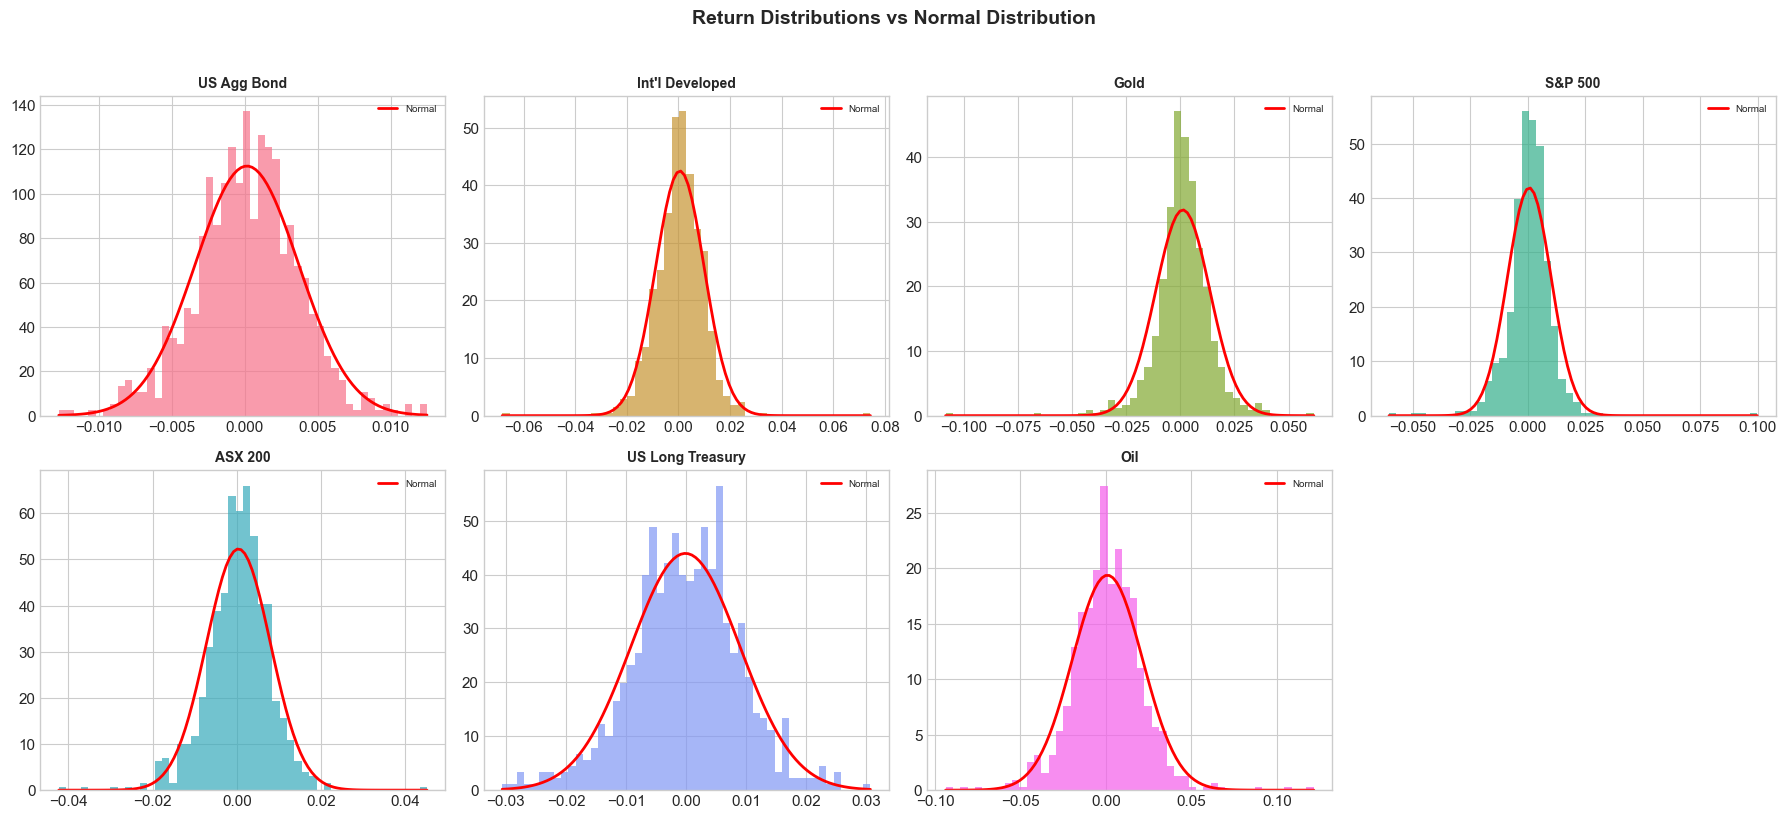

In [16]:
# Return distribution plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(returns.columns):
    ax = axes[i]
    returns[col].hist(bins=50, alpha=0.7, ax=ax, density=True, color=sns.color_palette("husl", len(returns.columns))[i])
    
    # Overlay normal distribution
    x = np.linspace(returns[col].min(), returns[col].max(), 100)
    ax.plot(x, norm.pdf(x, returns[col].mean(), returns[col].std()), 'r-', linewidth=2, label='Normal')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

# Remove empty subplot if odd number of assets
if len(returns.columns) < len(axes):
    for j in range(len(returns.columns), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle('Return Distributions vs Normal Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Portfolio Construction

We'll build a **diversified portfolio** with weights across all asset classes. You can adjust these weights to see how risk changes.

| Asset Class | Weight | Rationale |
|-------------|--------|-----------|
| Equities | 50% | Growth engine |
| Bonds | 25% | Stability & income |
| Commodities | 25% | Inflation hedge & diversification |


In [17]:
# Define portfolio weights (adjust these to experiment!)
weights = {
    'S&P 500':          0.25,
    'Int\'l Developed': 0.15,
    'ASX 200':          0.10,
    'US Long Treasury': 0.15,
    'US Agg Bond':      0.10,
    'Gold':             0.15,
    'Oil':              0.10
}

w = np.array([weights[col] for col in returns.columns])
assert abs(sum(w) - 1.0) < 1e-6, "Weights must sum to 1!"

# Portfolio returns
portfolio_returns = returns @ w

print("Portfolio Weights:")
for asset, weight in weights.items():
    print(f"  {asset:25s} {weight:6.1%}")
print(f"\n  {'Total':25s} {sum(w):6.1%}")

print(f"\n📊 Portfolio Statistics:")
print(f"  Annualised Return:     {portfolio_returns.mean() * 252:.2%}")
print(f"  Annualised Volatility: {portfolio_returns.std() * np.sqrt(252):.2%}")
print(f"  Sharpe Ratio (Rf=4%):  {(portfolio_returns.mean()*252 - 0.04)/(portfolio_returns.std()*np.sqrt(252)):.3f}")


Portfolio Weights:
  S&P 500                    25.0%
  Int'l Developed            15.0%
  ASX 200                    10.0%
  US Long Treasury           15.0%
  US Agg Bond                10.0%
  Gold                       15.0%
  Oil                        10.0%

  Total                     100.0%

📊 Portfolio Statistics:
  Annualised Return:     13.96%
  Annualised Volatility: 8.99%
  Sharpe Ratio (Rf=4%):  1.108


## 5. Value at Risk (VaR)

VaR answers: **"What is the maximum loss over a given time horizon at a given confidence level?"**

For example, a 1-day 95% VaR of -1.5% means:  
*"On 95% of trading days, the portfolio will not lose more than 1.5%."*

We implement **three methods**, each with different assumptions:

### Method 1: Historical VaR
- Uses **actual past returns** — no distributional assumptions
- Simply finds the percentile of the historical return distribution
- ✅ Captures fat tails, skewness
- ❌ Assumes the future looks like the past


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# METHOD 1: HISTORICAL VaR
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

confidence_levels = [0.90, 0.95, 0.99]

print("━" * 55)
print("HISTORICAL VaR (Portfolio)")
print("━" * 55)

historical_var = {}
for cl in confidence_levels:
    var = np.percentile(portfolio_returns, (1 - cl) * 100)
    historical_var[cl] = var
    print(f"  {cl:.0%} VaR:  {var:.4f}  ({var*100:.2f}%)")

print(f"\n  Interpretation: On 95% of days, portfolio loss")
print(f"  will not exceed {abs(historical_var[0.95])*100:.2f}%")
print(f"  For a $1M portfolio: max loss = ${abs(historical_var[0.95])*1_000_000:,.0f}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HISTORICAL VaR (Portfolio)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  90% VaR:  -0.0057  (-0.57%)
  95% VaR:  -0.0086  (-0.86%)
  99% VaR:  -0.0138  (-1.38%)

  Interpretation: On 95% of days, portfolio loss
  will not exceed 0.86%
  For a $1M portfolio: max loss = $8,590


### Method 2: Parametric (Variance-Covariance) VaR

- Assumes returns are **normally distributed**
- Uses the mean and standard deviation to compute VaR analytically
- $$\text{VaR}_{\alpha} = \mu + z_{\alpha} \cdot \sigma$$
- where $z_{\alpha}$ is the z-score at confidence level $\alpha$
- ✅ Fast, easy to compute, good for linear portfolios
- ❌ Underestimates risk if returns have fat tails (which they usually do!)


In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# METHOD 2: PARAMETRIC (VARIANCE-COVARIANCE) VaR
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

mu = portfolio_returns.mean()
sigma = portfolio_returns.std()

print("━" * 55)
print("PARAMETRIC VaR (Portfolio)")
print("━" * 55)

parametric_var = {}
for cl in confidence_levels:
    z = norm.ppf(1 - cl)
    var = mu + z * sigma
    parametric_var[cl] = var
    print(f"  {cl:.0%} VaR:  {var:.4f}  ({var*100:.2f}%)")

print(f"\n  μ = {mu:.6f},  σ = {sigma:.6f}")
print(f"  z(95%) = {norm.ppf(0.05):.4f}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PARAMETRIC VaR (Portfolio)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  90% VaR:  -0.0067  (-0.67%)
  95% VaR:  -0.0088  (-0.88%)
  99% VaR:  -0.0126  (-1.26%)

  μ = 0.000554,  σ = 0.005661
  z(95%) = -1.6449


### Method 3: Monte Carlo VaR

- **Simulates thousands of possible return scenarios** using the portfolio's mean and covariance structure
- Can handle **non-linear positions** and **complex distributions**
- ✅ Most flexible — can model any distribution or payoff structure
- ❌ Computationally expensive, depends on model assumptions

> 💡 **This is the method most commonly used by quant desks** for portfolios with options or other non-linear instruments.


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# METHOD 3: MONTE CARLO VaR
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

np.random.seed(42)
n_simulations = 10_000

# Use the covariance matrix to simulate correlated returns
cov_matrix = returns.cov()
mean_returns = returns.mean().values

# Simulate correlated multi-asset returns
simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, n_simulations)

# Portfolio simulated returns
simulated_portfolio = simulated_returns @ w

print("━" * 55)
print(f"MONTE CARLO VaR ({n_simulations:,} simulations)")
print("━" * 55)

mc_var = {}
for cl in confidence_levels:
    var = np.percentile(simulated_portfolio, (1 - cl) * 100)
    mc_var[cl] = var
    print(f"  {cl:.0%} VaR:  {var:.4f}  ({var*100:.2f}%)")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MONTE CARLO VaR (10,000 simulations)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  90% VaR:  -0.0068  (-0.68%)
  95% VaR:  -0.0088  (-0.88%)
  99% VaR:  -0.0127  (-1.27%)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VaR COMPARISON — All Methods
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        Historical Parametric Monte Carlo
90% VaR     -0.57%     -0.67%      -0.68%
95% VaR     -0.86%     -0.88%      -0.88%
99% VaR     -1.38%     -1.26%      -1.27%


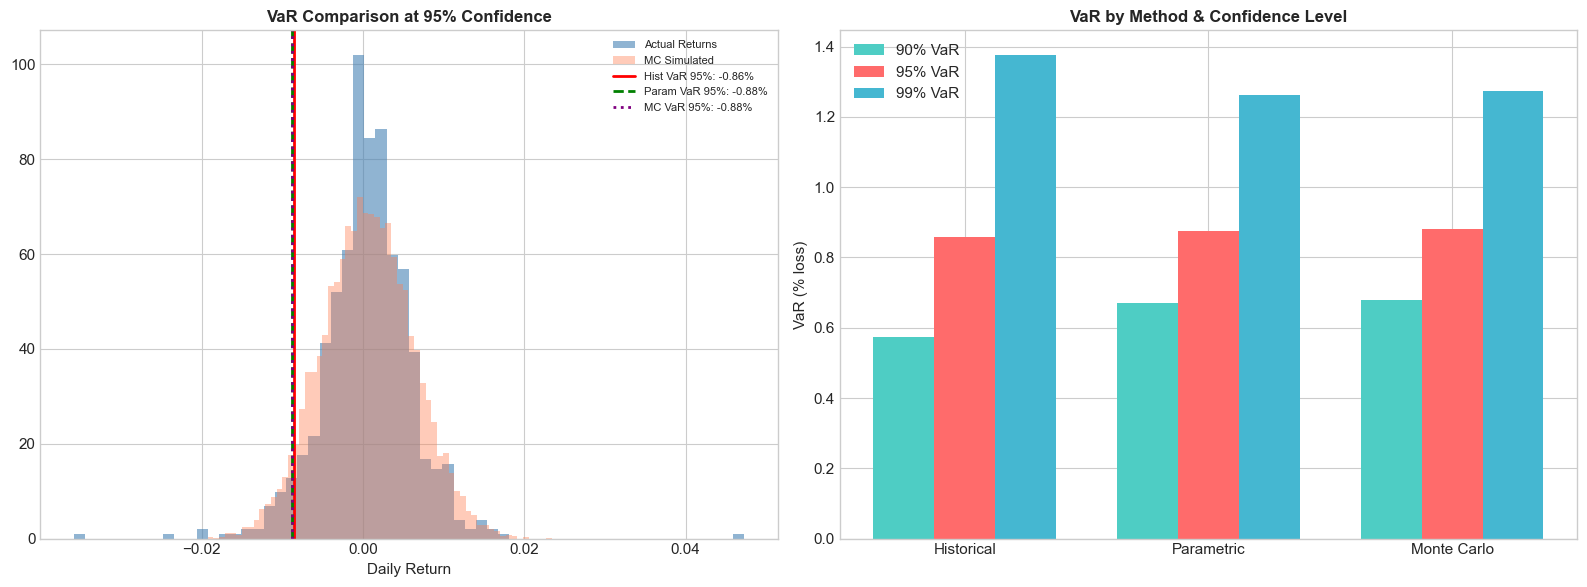

In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# COMPARE ALL THREE METHODS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

comparison = pd.DataFrame({
    'Historical': {f'{int(cl*100)}% VaR': f'{v*100:.2f}%' for cl, v in historical_var.items()},
    'Parametric': {f'{int(cl*100)}% VaR': f'{v*100:.2f}%' for cl, v in parametric_var.items()},
    'Monte Carlo': {f'{int(cl*100)}% VaR': f'{v*100:.2f}%' for cl, v in mc_var.items()}
})

print("━" * 55)
print("VaR COMPARISON — All Methods")
print("━" * 55)
print(comparison.to_string())

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram with VaR lines
ax = axes[0]
ax.hist(portfolio_returns, bins=60, density=True, alpha=0.6, color='steelblue', label='Actual Returns')
ax.hist(simulated_portfolio, bins=60, density=True, alpha=0.4, color='coral', label='MC Simulated')
ax.axvline(historical_var[0.95], color='red', linewidth=2, linestyle='-', label=f'Hist VaR 95%: {historical_var[0.95]*100:.2f}%')
ax.axvline(parametric_var[0.95], color='green', linewidth=2, linestyle='--', label=f'Param VaR 95%: {parametric_var[0.95]*100:.2f}%')
ax.axvline(mc_var[0.95], color='purple', linewidth=2, linestyle=':', label=f'MC VaR 95%: {mc_var[0.95]*100:.2f}%')
ax.set_title('VaR Comparison at 95% Confidence', fontsize=12, fontweight='bold')
ax.set_xlabel('Daily Return')
ax.legend(fontsize=8)

# Right: Bar chart comparison
ax2 = axes[1]
methods = ['Historical', 'Parametric', 'Monte Carlo']
var_90 = [abs(historical_var[0.90])*100, abs(parametric_var[0.90])*100, abs(mc_var[0.90])*100]
var_95 = [abs(historical_var[0.95])*100, abs(parametric_var[0.95])*100, abs(mc_var[0.95])*100]
var_99 = [abs(historical_var[0.99])*100, abs(parametric_var[0.99])*100, abs(mc_var[0.99])*100]

x = np.arange(len(methods))
width = 0.25
ax2.bar(x - width, var_90, width, label='90% VaR', color='#4ECDC4')
ax2.bar(x, var_95, width, label='95% VaR', color='#FF6B6B')
ax2.bar(x + width, var_99, width, label='99% VaR', color='#45B7D1')
ax2.set_ylabel('VaR (% loss)')
ax2.set_title('VaR by Method & Confidence Level', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.legend()

plt.tight_layout()
plt.show()


## 6. Expected Shortfall (CVaR)

VaR tells you the *threshold* — Expected Shortfall tells you **how bad it gets beyond that threshold**.

$$\text{ES}_{\alpha} = E[r \mid r \leq \text{VaR}_{\alpha}]$$

ES is the **average of all losses worse than VaR**. It's now the preferred risk measure under Basel III because:
1. It's **coherent** (satisfies subadditivity — portfolio ES ≤ sum of component ES)
2. It captures **tail risk** better than VaR
3. VaR only says "the loss won't exceed X with Y% probability" — ES says "when it *does* exceed X, the average loss is Z"

> 🎯 **Interview tip:** If asked "Why is CVaR better than VaR?", the key word is **subadditivity**. VaR can actually increase when you diversify (violating common sense), while CVaR always respects diversification benefits.


In [22]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXPECTED SHORTFALL (CVaR)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("━" * 60)
print("EXPECTED SHORTFALL vs VaR (Portfolio)")
print("━" * 60)
print(f"{'Confidence':<15} {'VaR':>10} {'ES (CVaR)':>12} {'ES/VaR':>10}")
print("─" * 50)

es_results = {}
for cl in confidence_levels:
    var = historical_var[cl]
    # ES = average of returns worse than VaR
    tail_losses = portfolio_returns[portfolio_returns <= var]
    es = tail_losses.mean()
    es_results[cl] = es
    ratio = es / var
    print(f"  {cl:.0%}          {var*100:>8.2f}%  {es*100:>10.2f}%  {ratio:>8.2f}x")

print(f"\n  At 95%, when losses exceed {historical_var[0.95]*100:.2f}%,")
print(f"  the average loss is {es_results[0.95]*100:.2f}%")
print(f"  For $1M: VaR = ${abs(historical_var[0.95])*1e6:,.0f}, ES = ${abs(es_results[0.95])*1e6:,.0f}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EXPECTED SHORTFALL vs VaR (Portfolio)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Confidence             VaR    ES (CVaR)     ES/VaR
──────────────────────────────────────────────────
  90%             -0.57%       -0.98%      1.70x
  95%             -0.86%       -1.25%      1.46x
  99%             -1.38%       -2.01%      1.46x

  At 95%, when losses exceed -0.86%,
  the average loss is -1.25%
  For $1M: VaR = $8,590, ES = $12,507


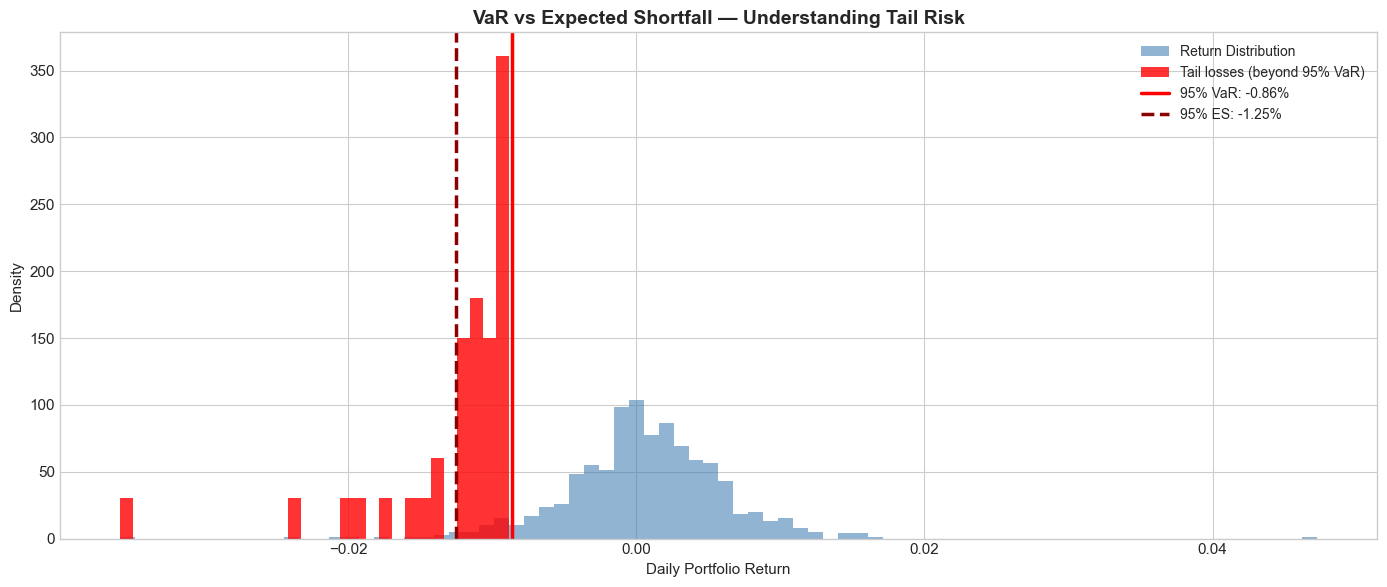

In [23]:
# Visualise the tail
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(portfolio_returns, bins=80, density=True, alpha=0.6, color='steelblue', label='Return Distribution')

# Shade the tail (losses beyond VaR)
var_95 = historical_var[0.95]
tail = portfolio_returns[portfolio_returns <= var_95]
ax.hist(tail, bins=30, density=True, alpha=0.8, color='red', label=f'Tail losses (beyond 95% VaR)')

ax.axvline(var_95, color='red', linewidth=2.5, linestyle='-', label=f'95% VaR: {var_95*100:.2f}%')
ax.axvline(es_results[0.95], color='darkred', linewidth=2.5, linestyle='--', label=f'95% ES: {es_results[0.95]*100:.2f}%')

ax.set_title('VaR vs Expected Shortfall — Understanding Tail Risk', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Portfolio Return')
ax.set_ylabel('Density')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 7. Volatility Modelling

Volatility isn't constant — it **clusters** (periods of high vol follow high vol). Two key models:

### Rolling Volatility
Simple moving window standard deviation. Easy but treats all observations equally.

### EWMA (Exponentially Weighted Moving Average)
JP Morgan's **RiskMetrics** model. Gives **more weight to recent observations** — adapts faster to market regime changes.

$$\sigma_t^2 = \lambda \cdot \sigma_{t-1}^2 + (1-\lambda) \cdot r_{t-1}^2$$

The standard decay factor is **λ = 0.94** (daily data).


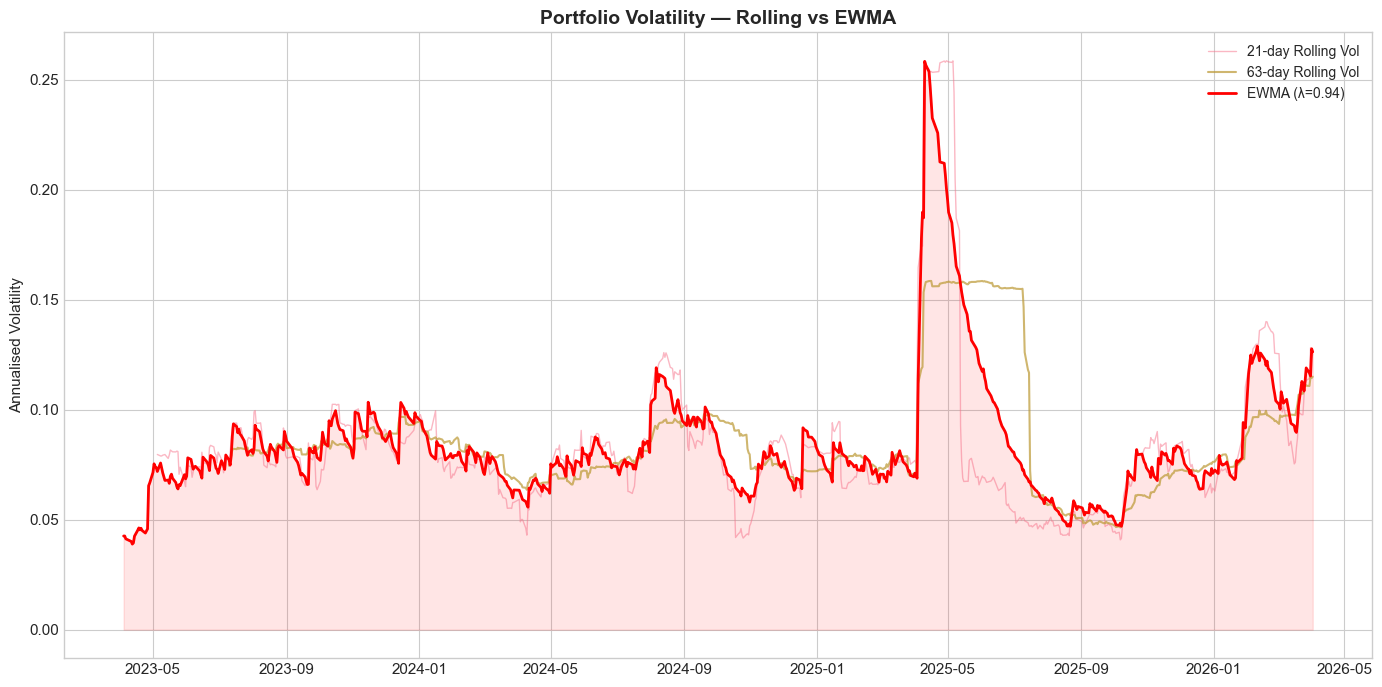

Current volatility estimates:
  21-day rolling: 12.51%
  63-day rolling: 11.50%
  EWMA (λ=0.94):  12.62%


In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# VOLATILITY MODELLING: Rolling vs EWMA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Rolling volatility (21-day = 1 month, 63-day = 1 quarter)
rolling_vol_21 = portfolio_returns.rolling(21).std() * np.sqrt(252)
rolling_vol_63 = portfolio_returns.rolling(63).std() * np.sqrt(252)

# EWMA volatility (lambda = 0.94, RiskMetrics standard)
lmbda = 0.94
ewma_var = np.zeros(len(portfolio_returns))
ewma_var[0] = portfolio_returns.iloc[0] ** 2

for t in range(1, len(portfolio_returns)):
    ewma_var[t] = lmbda * ewma_var[t-1] + (1 - lmbda) * portfolio_returns.iloc[t-1] ** 2

ewma_vol = pd.Series(np.sqrt(ewma_var) * np.sqrt(252), index=portfolio_returns.index)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(rolling_vol_21.index, rolling_vol_21, alpha=0.5, linewidth=1, label='21-day Rolling Vol')
ax.plot(rolling_vol_63.index, rolling_vol_63, alpha=0.7, linewidth=1.5, label='63-day Rolling Vol')
ax.plot(ewma_vol.index, ewma_vol, color='red', linewidth=2, label=f'EWMA (λ={lmbda})')

ax.set_title('Portfolio Volatility — Rolling vs EWMA', fontsize=14, fontweight='bold')
ax.set_ylabel('Annualised Volatility')
ax.legend(fontsize=10)
ax.fill_between(ewma_vol.index, 0, ewma_vol, alpha=0.1, color='red')
plt.tight_layout()
plt.show()

print(f"Current volatility estimates:")
print(f"  21-day rolling: {rolling_vol_21.iloc[-1]:.2%}")
print(f"  63-day rolling: {rolling_vol_63.iloc[-1]:.2%}")
print(f"  EWMA (λ=0.94):  {ewma_vol.iloc[-1]:.2%}")


## 8. Correlation & Diversification Analysis

Correlations tell you how assets **move together**. For risk management:
- **Correlation ≈ 1** → Assets move in lockstep → No diversification benefit
- **Correlation ≈ 0** → Assets move independently → Good diversification
- **Correlation < 0** → Assets move opposite → Excellent hedge

> ⚠️ **Critical insight:** Correlations **increase during crises** ("correlation breakdown"). The diversification you think you have in calm markets may disappear exactly when you need it most. This is why stress testing matters.


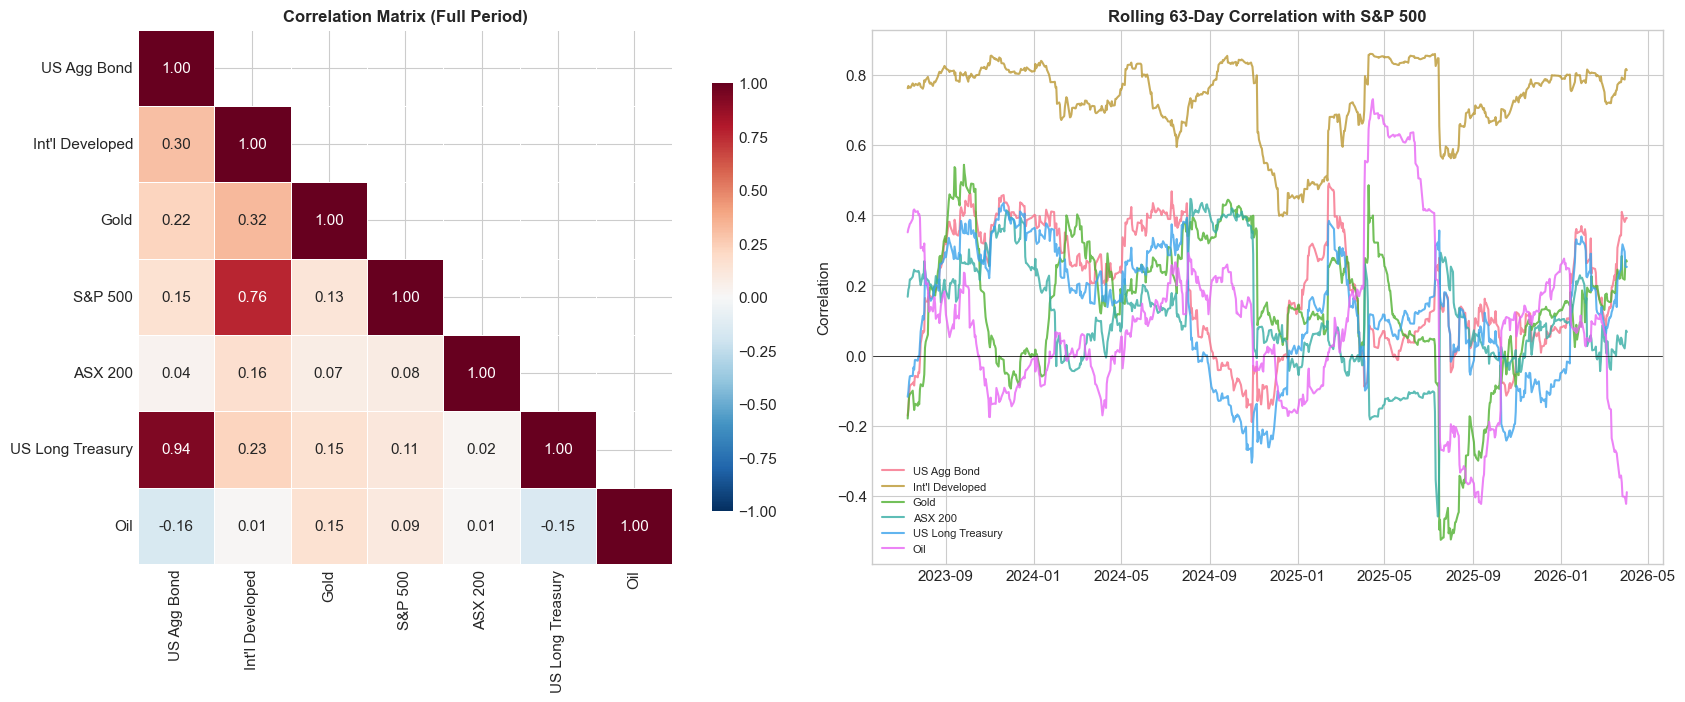

In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CORRELATION ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

corr_matrix = returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full-period correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix (Full Period)', fontsize=12, fontweight='bold')

# Rolling 63-day correlation between SPY and other assets
ax2 = axes[1]
spy_col = 'S&P 500'
for col in returns.columns:
    if col != spy_col:
        rolling_corr = returns[spy_col].rolling(63).corr(returns[col])
        ax2.plot(rolling_corr.index, rolling_corr, linewidth=1.5, label=f'{col}', alpha=0.8)

ax2.set_title(f'Rolling 63-Day Correlation with {spy_col}', fontsize=12, fontweight='bold')
ax2.set_ylabel('Correlation')
ax2.axhline(0, color='black', linewidth=0.5, linestyle='-')
ax2.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()


## 9. Stress Testing & Scenario Analysis

Stress tests go beyond VaR by asking: **"What happens to our portfolio if a specific crisis event occurs?"**

We test two types:
1. **Historical scenarios** — Apply actual crisis-period returns
2. **Hypothetical shocks** — Apply custom market moves (e.g., equities -20%, rates +200bps)

> 🏦 **Industry context:** Banks must run regulatory stress tests (e.g., Fed's CCAR/DFAST in the US, APRA stress tests in Australia). This is a core skill for market risk analysts.


In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STRESS TESTING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Hypothetical stress scenarios (daily shocks)
scenarios = {
    'Equity Crash (-8%)': {
        'S&P 500': -0.08, 'Int\'l Developed': -0.07, 'ASX 200': -0.06,
        'US Long Treasury': 0.02, 'US Agg Bond': 0.01, 'Gold': 0.03, 'Oil': -0.05
    },
    'Rate Shock (+200bps)': {
        'S&P 500': -0.03, 'Int\'l Developed': -0.03, 'ASX 200': -0.03,
        'US Long Treasury': -0.12, 'US Agg Bond': -0.05, 'Gold': -0.01, 'Oil': -0.02
    },
    'Commodity Spike': {
        'S&P 500': -0.02, 'Int\'l Developed': -0.02, 'ASX 200': 0.01,
        'US Long Treasury': 0.01, 'US Agg Bond': 0.00, 'Gold': 0.05, 'Oil': 0.10
    },
    'Flight to Safety': {
        'S&P 500': -0.05, 'Int\'l Developed': -0.06, 'ASX 200': -0.05,
        'US Long Treasury': 0.04, 'US Agg Bond': 0.02, 'Gold': 0.04, 'Oil': -0.08
    },
    'Global Sell-Off': {
        'S&P 500': -0.06, 'Int\'l Developed': -0.07, 'ASX 200': -0.06,
        'US Long Treasury': -0.03, 'US Agg Bond': -0.02, 'Gold': -0.02, 'Oil': -0.08
    }
}

print("━" * 65)
print("STRESS TEST RESULTS")
print("━" * 65)
print(f"{'Scenario':<25} {'Portfolio Impact':>15} {'$1M P&L':>12}")
print("─" * 55)

stress_results = {}
for scenario_name, shocks in scenarios.items():
    shock_vector = np.array([shocks.get(col, 0) for col in returns.columns])
    portfolio_impact = shock_vector @ w
    stress_results[scenario_name] = portfolio_impact
    print(f"  {scenario_name:<25} {portfolio_impact:>13.2%}  ${portfolio_impact * 1_000_000:>10,.0f}")

# Worst scenario
worst = min(stress_results, key=stress_results.get)
print(f"\n  ⚠️  Worst scenario: {worst} → {stress_results[worst]:.2%}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STRESS TEST RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Scenario                  Portfolio Impact      $1M P&L
───────────────────────────────────────────────────────
  Equity Crash (-8%)               -3.30%  $   -33,000
  Rate Shock (+200bps)             -4.15%  $   -41,500
  Commodity Spike                   1.20%  $    12,000
  Flight to Safety                 -2.05%  $   -20,500
  Global Sell-Off                  -4.90%  $   -49,000

  ⚠️  Worst scenario: Global Sell-Off → -4.90%


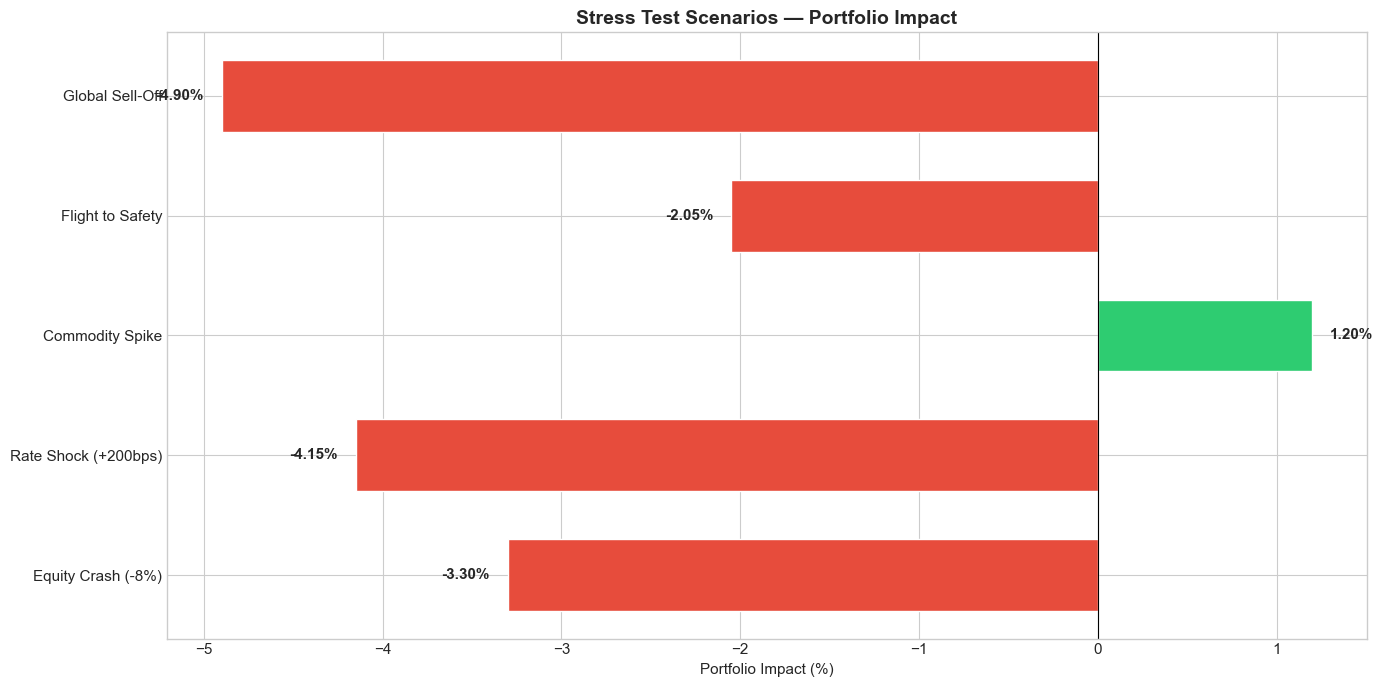

In [27]:
# Stress test waterfall chart
fig, ax = plt.subplots(figsize=(14, 7))

scenario_names = list(stress_results.keys())
impacts = [stress_results[s] * 100 for s in scenario_names]
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in impacts]

bars = ax.barh(scenario_names, impacts, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, impacts):
    x_pos = val + (0.1 if val >= 0 else -0.1)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}%',
            va='center', ha='left' if val >= 0 else 'right', fontweight='bold', fontsize=11)

ax.set_xlabel('Portfolio Impact (%)')
ax.set_title('Stress Test Scenarios — Portfolio Impact', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## 10. Risk Decomposition — Component VaR

Component VaR answers: **"How much does each asset contribute to total portfolio risk?"**

This is essential for **risk budgeting** — allocating risk where you expect the highest return.

$$\text{Component VaR}_i = w_i \cdot \frac{\partial \text{VaR}}{\partial w_i} = w_i \cdot \beta_i \cdot \text{VaR}_p$$

where $\beta_i$ is the asset's beta to the portfolio.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RISK DECOMPOSITION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                 Weight Ann. Vol  Beta to Port  Risk Contrib (%) Component VaR ($1M)
US Agg Bond       10.0%    5.63%         0.281               2.8              $4,152
Int'l Developed   15.0%   14.90%         1.285              19.3             $28,491
Gold              15.0%   19.89%         1.281              19.2             $28,406
S&P 500           25.0%   15.12%         1.234              30.8             $45,594
ASX 200           10.0%   12.11%         0.327               3.3              $4,839
US Long Treasury  15.0%   14.42%         0.642               9.6             $14,233
Oil               10.0%   32.71%         1.495              14.9             $22,092

Portfolio annualised volatility: 8.99%


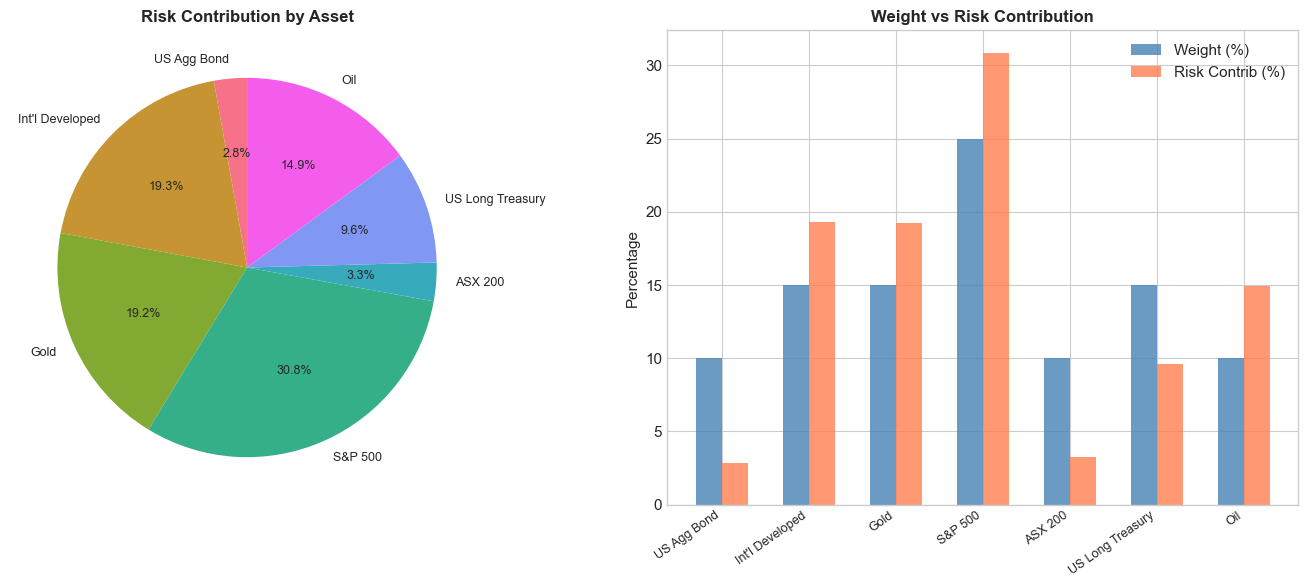

In [28]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# COMPONENT VaR & RISK DECOMPOSITION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Portfolio variance and vol
port_var = w @ cov_matrix.values @ w
port_vol = np.sqrt(port_var)

# Marginal contribution to risk (MCR)
mcr = (cov_matrix.values @ w) / port_vol

# Component risk (absolute)
component_risk = w * mcr

# Component risk (percentage)
component_pct = component_risk / port_vol * 100

# Component VaR (at 95%)
z_95 = norm.ppf(0.05)
comp_var = component_risk * abs(z_95) * np.sqrt(252)

risk_decomp = pd.DataFrame({
    'Weight': [f'{x:.1%}' for x in w],
    'Ann. Vol': [f'{returns[col].std()*np.sqrt(252):.2%}' for col in returns.columns],
    'Beta to Port': (cov_matrix.values @ w / port_var).round(3),
    'Risk Contrib (%)': component_pct.round(1),
    'Component VaR ($1M)': [f'${abs(x)*1e6:,.0f}' for x in comp_var]
}, index=returns.columns)

print("━" * 70)
print("RISK DECOMPOSITION")
print("━" * 70)
print(risk_decomp.to_string())
print(f"\nPortfolio annualised volatility: {port_vol * np.sqrt(252):.2%}")

# Pie chart of risk contribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Risk contribution
colors_pie = sns.color_palette("husl", len(returns.columns))
axes[0].pie(np.abs(component_pct), labels=returns.columns, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Risk Contribution by Asset', fontsize=12, fontweight='bold')

# Weight vs Risk contribution
x_pos = np.arange(len(returns.columns))
axes[1].bar(x_pos - 0.15, w * 100, 0.3, label='Weight (%)', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + 0.15, np.abs(component_pct), 0.3, label='Risk Contrib (%)', color='coral', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(returns.columns, rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Percentage')
axes[1].set_title('Weight vs Risk Contribution', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Risk Dashboard Summary

Pulling everything together into a single risk report view.


In [29]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXECUTIVE RISK DASHBOARD
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

portfolio_value = 1_000_000  # Notional

print("=" * 65)
print("        MARKET RISK DASHBOARD — EXECUTIVE SUMMARY")
print("=" * 65)
print(f"  Portfolio Value:  ${portfolio_value:>12,.0f}")
print(f"  Date Range:       {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"  Assets:           {len(returns.columns)}")
print()
print("  ┌─ RETURN METRICS ───────────────────────────┐")
print(f"  │  Annualised Return:     {portfolio_returns.mean()*252:>8.2%}           │")
print(f"  │  Annualised Volatility: {portfolio_returns.std()*np.sqrt(252):>8.2%}           │")
print(f"  │  Sharpe Ratio (Rf=4%):  {(portfolio_returns.mean()*252-0.04)/(portfolio_returns.std()*np.sqrt(252)):>8.3f}           │")
print(f"  │  Max Daily Loss:        {portfolio_returns.min():>8.2%}           │")
print("  └─────────────────────────────────────────────┘")
print()
print("  ┌─ VALUE AT RISK (95%, 1-day) ────────────────┐")
print(f"  │  Historical VaR: {historical_var[0.95]*100:>7.2f}%  (${abs(historical_var[0.95])*portfolio_value:>9,.0f}) │")
print(f"  │  Parametric VaR: {parametric_var[0.95]*100:>7.2f}%  (${abs(parametric_var[0.95])*portfolio_value:>9,.0f}) │")
print(f"  │  Monte Carlo VaR:{mc_var[0.95]*100:>7.2f}%  (${abs(mc_var[0.95])*portfolio_value:>9,.0f}) │")
print("  └─────────────────────────────────────────────┘")
print()
print("  ┌─ EXPECTED SHORTFALL (95%) ──────────────────┐")
print(f"  │  CVaR:           {es_results[0.95]*100:>7.2f}%  (${abs(es_results[0.95])*portfolio_value:>9,.0f}) │")
print("  └─────────────────────────────────────────────┘")
print()
print("  ┌─ CURRENT VOLATILITY ────────────────────────┐")
print(f"  │  EWMA (λ=0.94):         {ewma_vol.iloc[-1]:>8.2%}           │")
print(f"  │  21-day Rolling:         {rolling_vol_21.iloc[-1]:>8.2%}           │")
print("  └─────────────────────────────────────────────┘")
print()
print("  ┌─ WORST STRESS SCENARIO ─────────────────────┐")
print(f"  │  {worst:<25}  {stress_results[worst]:>7.2%}         │")
print(f"  │  P&L Impact: ${stress_results[worst]*portfolio_value:>10,.0f}                   │")
print("  └─────────────────────────────────────────────┘")
print("=" * 65)


        MARKET RISK DASHBOARD — EXECUTIVE SUMMARY
  Portfolio Value:  $   1,000,000
  Date Range:       2023-04-03 to 2026-04-02
  Assets:           7

  ┌─ RETURN METRICS ───────────────────────────┐
  │  Annualised Return:       13.96%           │
  │  Annualised Volatility:    8.99%           │
  │  Sharpe Ratio (Rf=4%):     1.108           │
  │  Max Daily Loss:          -3.58%           │
  └─────────────────────────────────────────────┘

  ┌─ VALUE AT RISK (95%, 1-day) ────────────────┐
  │  Historical VaR:   -0.86%  ($    8,590) │
  │  Parametric VaR:   -0.88%  ($    8,757) │
  │  Monte Carlo VaR:  -0.88%  ($    8,807) │
  └─────────────────────────────────────────────┘

  ┌─ EXPECTED SHORTFALL (95%) ──────────────────┐
  │  CVaR:             -1.25%  ($   12,507) │
  └─────────────────────────────────────────────┘

  ┌─ CURRENT VOLATILITY ────────────────────────┐
  │  EWMA (λ=0.94):           12.62%           │
  │  21-day Rolling:           12.51%           │
  └──────────────

## 🚀 Next Steps & Extensions

Now that you've built the core, here are ways to extend this for your portfolio and interviews:

### Quick Wins
- [ ] **Backtest VaR** — Compare predicted VaR to actual losses (Kupiec test for VaR exceedances)
- [ ] **Add GARCH modelling** — More sophisticated volatility model (`arch` library)
- [ ] **10-day VaR** — Scale to regulatory holding period (√10 rule vs actual 10-day returns)

### Intermediate
- [ ] **Marginal VaR** — How does adding $1 of an asset change portfolio risk?
- [ ] **Conditional correlation** — Correlations in bull vs bear markets
- [ ] **Risk parity portfolio** — Optimise weights so each asset contributes equal risk

### Advanced
- [ ] **Copula-based VaR** — Model non-linear dependence structures
- [ ] **Options Greeks** — Extend to portfolios with non-linear payoffs
- [ ] **Real-time data feed** — Connect to live market data API

### Interview Talking Points from This Project
1. "I implemented three VaR methodologies and compared their assumptions and outputs"
2. "I showed that parametric VaR underestimates tail risk due to fat tails in returns"
3. "I built EWMA volatility following JP Morgan's RiskMetrics framework"
4. "I decomposed portfolio risk into component VaR for risk budgeting"
5. "I designed stress test scenarios including equity crashes and rate shocks"
